## 1. Loading csv files from data folder

In [1]:
import pandas as pd
from pathlib import Path

data_dir = Path("../data/raw")  # relative to the notebook folder

customers = pd.read_csv(data_dir / "customers.csv")
order_items = pd.read_csv(data_dir / "order_items.csv")
orders = pd.read_csv(data_dir / "orders.csv")
products = pd.read_csv(data_dir / "products.csv")


There are four different files in the dataset: customers.csv, order_items.csv, orders.csv, and products.csv

In [2]:
customers.head()

,customer_id,gender,first_name,last_name,full_name,age,city,signup_date
0,0,Female,Riya,Malhotra,Riya Malhotra,19.0,Pune,2024-09-30
1,1,Male,Suresh,Gupta,Suresh Gupta,27.0,Hyderabad,2025-11-13
2,2,Male,Amit,Reddy,Amit Reddy,37.0,Bangalore,2023-04-18
3,3,Male,Rohit,Malhotra,Rohit Malhotra,59.0,Pune,2024-12-28
4,4,Female,Neha,Iyer,Neha Iyer,56.0,Delhi,2024-08-19


In [3]:
order_items.head()

,order_id,product_id,quantity,unit_price,discount,net_amount
0,Byk-0,6514,3,3614.06,275.99,10566.19
1,Byk-0,2222,4,4539.08,1090.19,17066.13
2,Byk-0,40137,4,85.64,12.91,329.65
3,Byk-1,48440,3,1384.96,317.69,3837.19
4,Byk-1,52122,1,3002.00,108.78,2893.22


In [4]:
orders.head()

,order_id,customer_id,order_date,order_ts,city,state,payment_method,order_status,total_amount
0,Byk-0,651198,2025-11-20,2025-11-20T16:38:56.000Z,Delhi,DL,Wallet,Cancelled,1755.48
1,Byk-1,192749,2025-12-07,2025-12-07T12:24:38.000Z,Pune,MH,Debit Card,Delivered,6055.63
2,Byk-2,217349,2025-04-10,2025-04-10T23:41:58.000Z,Chennai,TN,Credit Card,Delivered,1413.51
3,Byk-3,405295,2025-10-31,2025-10-31T13:24:18.000Z,Delhi,DL,COD,Delivered,3157.44
4,Byk-4,93506,2025-06-21,2025-06-21T19:14:54.000Z,Kolkata,WB,Debit Card,Delivered,4219.23


In [5]:
products.head()

,product_id,brand,category,sub_category,mrp
0,0,Nykaa Naturals,Fragrance,Compact,4833.00
1,1,Lakme,Personal Care,Serum,710.60
2,2,Nykaa Naturals,Personal Care,Eyeliner,3217.86
3,3,WOW Skin Science,Skincare,Sanitizer,4979.63
4,4,Lakme,Haircare,Soap,347.29


## 2. Counting of **MISSING VALUE** for each file

In [6]:
for name, df in [
    ("customers", customers),
    ("order_items", order_items),
    ("orders", orders),
    ("products", products),
]:
    print(f"{name} missing values:")
    print(df.isna().sum())
    print()

customers missing values:
customer_id        0
gender         20059
first_name     10045
last_name       9978
full_name      19933
age            19960
city           19776
signup_date        0
dtype: int64

order_items missing values:
order_id          0
product_id        0
quantity          0
unit_price        0
discount      29984
net_amount        0
dtype: int64

orders missing values:
order_id              0
customer_id           0
order_date            0
order_ts              0
city              19844
state             19993
payment_method    29888
order_status       9934
total_amount          0
dtype: int64

products missing values:
product_id         0
brand           5135
category        5106
sub_category    5066
mrp             2946
dtype: int64



In [7]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
}

for name, df in tables.items():
    full_dup = df.duplicated(keep=False).sum()
    print(f"{name}: full-row duplicates = {full_dup}")

    # optional: key-based duplicates (if those cols exist)
    if name == "customers" and "customer_id" in df:
        print("  by customer_id:", df.duplicated(subset=["customer_id"], keep=False).sum())
    if name == "orders" and "order_id" in df:
        print("  by order_id:", df.duplicated(subset=["order_id"], keep=False).sum())
    if name == "order_items" and {"order_id", "product_id"}.issubset(df):
        print("  by (order_id, product_id):", df.duplicated(subset=["order_id", "product_id"], keep=False).sum())
    if name == "products" and "product_id" in df:
        print("  by product_id:", df.duplicated(subset=["product_id"], keep=False).sum())
    print()

customers: full-row duplicates = 0
  by customer_id: 0

orders: full-row duplicates = 0
  by order_id: 0

order_items: full-row duplicates = 0
  by (order_id, product_id): 0

products: full-row duplicates = 0
  by product_id: 0



In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1) basic missing / dtype / shape
for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items), ("products", products)]:
    print(name, "shape", df.shape)
    print(df.dtypes)
    print("missing:", df.isna().sum().sort_values(ascending=False).head(10))
    print()
    print()


customers shape (1000000, 8)
customer_id      int64
gender          object
first_name      object
last_name       object
full_name       object
age            float64
city            object
signup_date     object
dtype: object
missing: gender         20059
age            19960
full_name      19933
city           19776
first_name     10045
last_name       9978
customer_id        0
signup_date        0
dtype: int64


orders shape (1000000, 9)
order_id           object
customer_id         int64
order_date         object
order_ts           object
city               object
state              object
payment_method     object
order_status       object
total_amount      float64
dtype: object
missing: payment_method    29888
state             19993
city              19844
order_status       9934
order_id              0
customer_id           0
order_date            0
order_ts              0
total_amount          0
dtype: int64


order_items shape (300000, 6)
order_id       object
product_id     

In [9]:

# 2) descriptive stats (numeric + object)
for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items), ("products", products)]:
    print(f"--- {name} numeric stats ---")
    display(df.describe(include="number").T)
    print(f"--- {name} object/categorical counts ---")
    display(df.describe(include="object").T)
    print()


--- customers numeric stats ---


,count,mean,std,min,25%,50%,75%,max
customer_id,1000000.0,499999.500000,288675.278932,0.0,249999.75,499999.5,749999.25,999999.0
age,980040.0,38.982558,12.407738,18.0,28.00,39.0,50.00,60.0


--- customers object/categorical counts ---


,count,unique,top,freq
gender,979941,2,Female,685760
first_name,989955,30,Neha,45585
last_name,990022,15,Verma,66319
full_name,980067,450,Swati Banerjee,3129
city,980224,7,Hyderabad,140537
signup_date,1000000,1500,2023-03-30,765



--- orders numeric stats ---


...

,count,unique,top,freq
order_id,300000,100000,Byk-0,3



--- products numeric stats ---


,count,mean,std,min,25%,50%,75%,max
product_id,100000.0,49999.500000,28867.657797,0.00,24999.75,49999.5,74999.2500,99999.00
mrp,97054.0,2527.182303,1430.243970,50.01,1287.28,2528.9,3768.1525,4999.99


--- products object/categorical counts ---


,count,unique,top,freq
brand,94865,12,Maybelline,8094
category,94894,5,Skincare,19158
sub_category,94934,21,Serum,7750


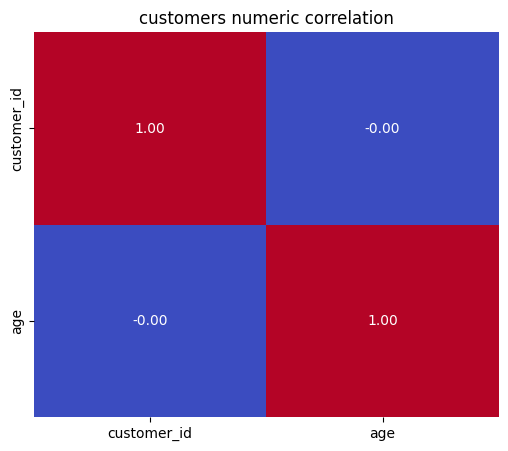

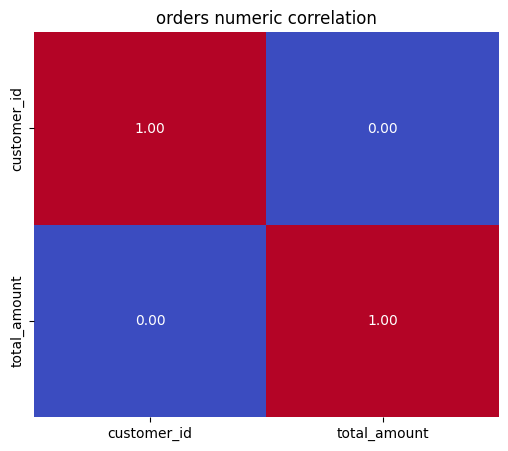

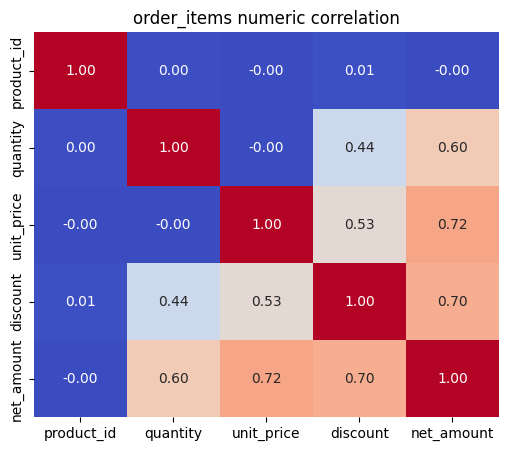

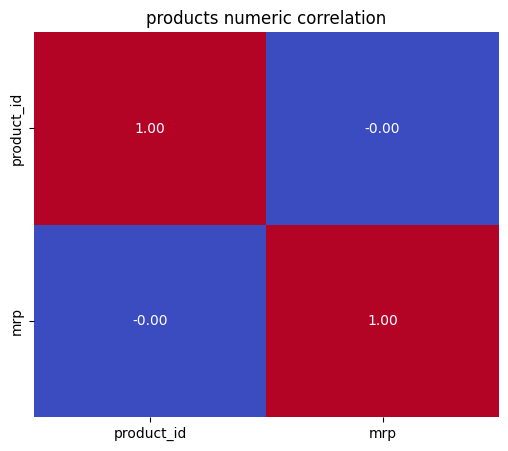

In [10]:

# 3) correlations / heatmap for numeric columns
for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items), ("products", products)]:
    corr = df.select_dtypes("number").corr()
    if corr.shape[0] > 1:
        plt.figure(figsize=(6, 5))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
        plt.title(f"{name} numeric correlation")
        plt.show()


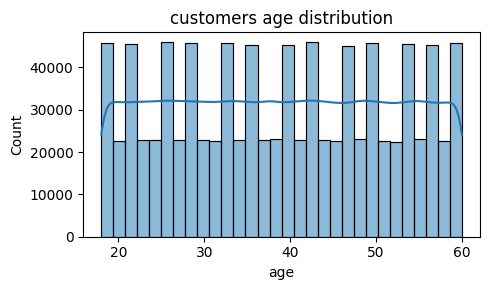

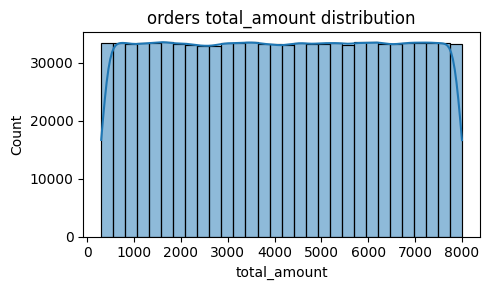

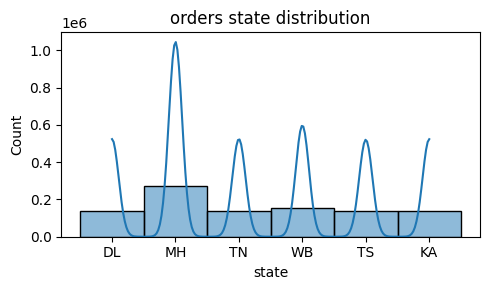

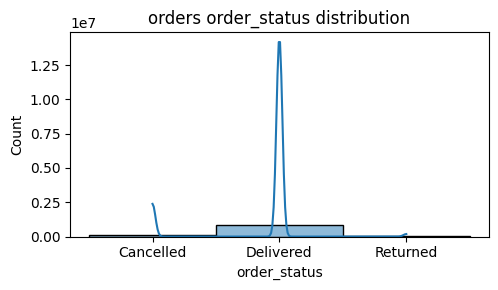

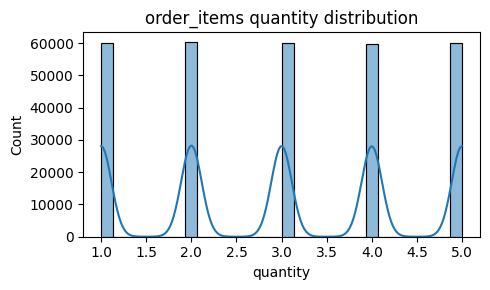

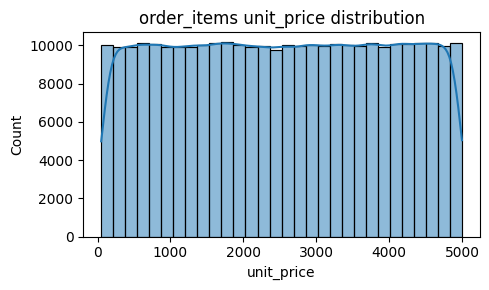

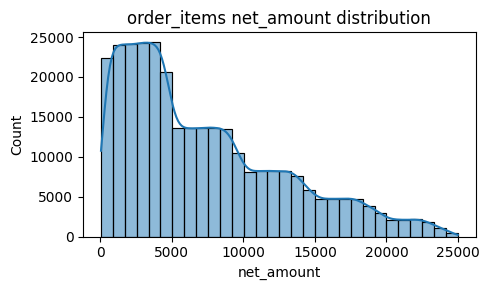

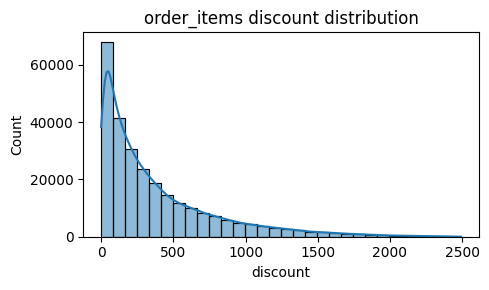

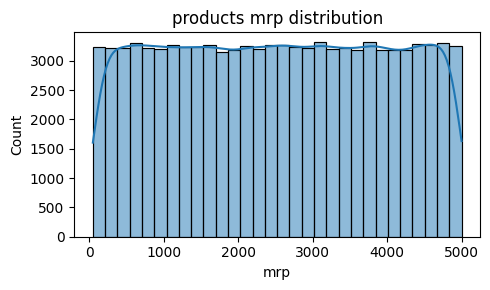

In [11]:

# 4) distributions for key numeric columns (histograms)
num_cols = {
    "customers": ["age"],
    "orders": ["total_amount", "state", "order_status"],  
    "order_items": ["quantity", "unit_price", "net_amount", "discount"],
    "products": ["mrp"],  
}
for name, cols in num_cols.items():
    df = locals()[name]
    for c in cols:
        if c in df:
            plt.figure(figsize=(5, 3))
            sns.histplot(df[c].dropna(), kde=True, bins=30)
            plt.title(f"{name} {c} distribution")
            plt.tight_layout()
            plt.show()



In [12]:
# 5) top categories for a few categorical columns
cat_cols = {
    "customers": ["gender", "city"],
    "orders": ["state", "city"],
    "order_items": ["product_id"],
    "products": ["brand", "category", "sub_category"],
}
for name, cols in cat_cols.items():
    df = locals()[name]
    for c in cols:
        if c in df:
            print(name, c, df[c].value_counts(dropna=False).head(10))
            print()

customers gender gender
Female    685760
Male      294181
NaN        20059
Name: count, dtype: int64

customers city city
Hyderabad    140537
Delhi        140370
Chennai      140127
Kolkata      139972
Bangalore    139864
Pune         139745
Mumbai       139609
NaN           19776
Name: count, dtype: int64

orders state state
MH     274395
WB     156720
TN     137550
DL     137393
KA     137327
TS     136622
NaN     19993
Name: count, dtype: int64

orders city city
Chennai      140322
Delhi        140199
Mumbai       140159
Bangalore    140143
Kolkata      140070
Pune         139791
Hyderabad    139472
NaN           19844
Name: count, dtype: int64

order_items product_id product_id
42715     10
126566    10
139933    10
22571     10
122565    10
119935     9
97062      9
139073     9
3031       9
105855     9
Name: count, dtype: int64

products brand brand
Maybelline           8094
Lakme                8050
Pond's               7989
Himalaya             7962
The Body Shop        7944
M

##### Let's do a quick EDA.

1. How many orders per month?

In [13]:
orders.head()

,order_id,customer_id,order_date,order_ts,city,state,payment_method,order_status,total_amount
0,Byk-0,651198,2025-11-20,2025-11-20T16:38:56.000Z,Delhi,DL,Wallet,Cancelled,1755.48
1,Byk-1,192749,2025-12-07,2025-12-07T12:24:38.000Z,Pune,MH,Debit Card,Delivered,6055.63
2,Byk-2,217349,2025-04-10,2025-04-10T23:41:58.000Z,Chennai,TN,Credit Card,Delivered,1413.51
3,Byk-3,405295,2025-10-31,2025-10-31T13:24:18.000Z,Delhi,DL,COD,Delivered,3157.44
4,Byk-4,93506,2025-06-21,2025-06-21T19:14:54.000Z,Kolkata,WB,Debit Card,Delivered,4219.23


In [14]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
orders['order_month'] = orders['order_date'].dt.to_period('M')
orders['order_month'] 

0         2025-11
1         2025-12
2         2025-04
3         2025-10
4         2025-06
           ...   
999995    2025-10
999996    2025-07
999997    2025-07
999998    2025-10
999999    2025-07
Name: order_month, Length: 1000000, dtype: period[M]

In [15]:
count_by_month_components = orders.groupby([orders['order_month'].dt.year, orders['order_month'].dt.month]).size()
print("Count using year and month components:")
print(count_by_month_components)

Count using year and month components:
order_month  order_month
2025         3              68223
             4              82267
             5              84933
             6              82558
             7              85120
             8              84771
             9              82220
             10             85009
             11             82215
             12             84617
2026         1              85086
             2              76561
             3              16420
dtype: int64


2. Top selling products?

In [16]:
products.head()

,product_id,brand,category,sub_category,mrp
0,0,Nykaa Naturals,Fragrance,Compact,4833.00
1,1,Lakme,Personal Care,Serum,710.60
2,2,Nykaa Naturals,Personal Care,Eyeliner,3217.86
3,3,WOW Skin Science,Skincare,Sanitizer,4979.63
4,4,Lakme,Haircare,Soap,347.29


In [17]:
order_items.head(5)

,order_id,product_id,quantity,unit_price,discount,net_amount
0,Byk-0,6514,3,3614.06,275.99,10566.19
1,Byk-0,2222,4,4539.08,1090.19,17066.13
2,Byk-0,40137,4,85.64,12.91,329.65
3,Byk-1,48440,3,1384.96,317.69,3837.19
4,Byk-1,52122,1,3002.00,108.78,2893.22


In [18]:
top1_product = order_items.groupby('product_id')['quantity'].sum().sort_values(ascending=False).head(1)
pd.merge(top1_product, products, on='product_id', how='inner')

,product_id,quantity,brand,category,sub_category,mrp
0,97062,35,Forest Essentials,Fragrance,Body Lotion,2362.34


3. Average order value?

In [19]:
result = order_items.groupby('product_id')['net_amount'].mean().sort_values(ascending=False).round(2)
result


product_id
117217    24954.95
105891    24912.85
333       24892.00
148216    24888.15
15739     24881.65
            ...   
34671        52.01
37725        50.37
5421         50.37
7819         50.31
60014        48.67
Name: net_amount, Length: 129679, dtype: float64

4. Most valuable customers (MVC)?

A Most Valuable Customer (MVC) in retail is typically defined by high customer lifetime value (CLV)—the total projected profit a customer generates, not just a single purchase. They are identified by high-frequency purchasing, high average order value, brand advocacy, and low price sensitivity.

In [20]:
orders.head()

,order_id,customer_id,order_date,order_ts,city,state,payment_method,order_status,total_amount,order_month
0,Byk-0,651198,2025-11-20,2025-11-20T16:38:56.000Z,Delhi,DL,Wallet,Cancelled,1755.48,2025-11
1,Byk-1,192749,2025-12-07,2025-12-07T12:24:38.000Z,Pune,MH,Debit Card,Delivered,6055.63,2025-12
2,Byk-2,217349,2025-04-10,2025-04-10T23:41:58.000Z,Chennai,TN,Credit Card,Delivered,1413.51,2025-04
3,Byk-3,405295,2025-10-31,2025-10-31T13:24:18.000Z,Delhi,DL,COD,Delivered,3157.44,2025-10
4,Byk-4,93506,2025-06-21,2025-06-21T19:14:54.000Z,Kolkata,WB,Debit Card,Delivered,4219.23,2025-06


In [21]:
top1_customer = orders.groupby('customer_id')['order_id'].size().sort_values(ascending=False).head(10)
pd.merge(top1_customer, customers, on='customer_id', how='inner')

,customer_id,order_id,gender,first_name,last_name,full_name,age,city,signup_date
0,351856,9,Female,Anjali,Singh,Anjali Singh,29.0,Kolkata,2024-08-10
1,471838,8,Male,Vikas,Gupta,Vikas Gupta,50.0,Pune,2022-08-02
2,946590,8,Female,Sneha,Singh,Sneha Singh,56.0,Bangalore,2023-10-18
3,584872,8,Male,Suresh,Patel,Suresh Patel,42.0,Mumbai,2024-01-25
4,661060,8,Female,Sneha,Verma,Sneha Verma,NaN,Mumbai,2023-05-25
5,678827,8,Male,NaN,Khan,NaN,24.0,Delhi,2025-08-03
6,933694,8,Female,Shreya,Sharma,Shreya Sharma,22.0,Delhi,2023-08-15
7,704125,8,Male,Ankit,Sharma,Ankit Sharma,34.0,Pune,2025-02-17
8,439068,8,Female,Meera,Verma,Meera Verma,NaN,Hyderabad,2022-06-29
9,981581,7,Female,Preeti,Agarwal,Preeti Agarwal,20.0,Hyderabad,2025-02-25


5. Most active state (has the most customer and total amount) in 2025?

In [22]:
order_in_2025 = orders[orders['order_date'].dt.year == 2025]
order_by_state = order_in_2025.groupby(['state'])['order_id'].size().sort_values(ascending=False).head(10)
amount_by_state = order_in_2025.groupby(['state'])['total_amount'].sum().sort_values(ascending=False).head(10)

# Convert Series to DataFrames so they have mergeable columns
df_orders = order_by_state.reset_index(name='order_count')
df_amount = amount_by_state.reset_index(name='total_revenue')

# Merge and sort by revenue (or order_count)
top_combined = pd.merge(df_orders, df_amount, on='state', how='inner')
top1_combined = top_combined.sort_values(by=['total_revenue', 'order_count'], ascending=False).head(1)

print(top1_combined)

  state  order_count  total_revenue
0    MH       225630   9.369628e+08


#### A quick overview: 

* Sales trend chart

In [23]:
order_by_month = orders.groupby([orders['order_month'].dt.year, orders['order_month'].dt.month]).size()
order_by_month

order_month  order_month
2025         3              68223
             4              82267
             5              84933
             6              82558
             7              85120
             8              84771
             9              82220
             10             85009
             11             82215
             12             84617
2026         1              85086
             2              76561
             3              16420
dtype: int64

/var/folders/3b/8cnrvmc53q97m9nqbnvfytlm0000gn/T/ipykernel_2489/2802861177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=amount_by_state.index, y=amount_by_state.values, palette="viridis")


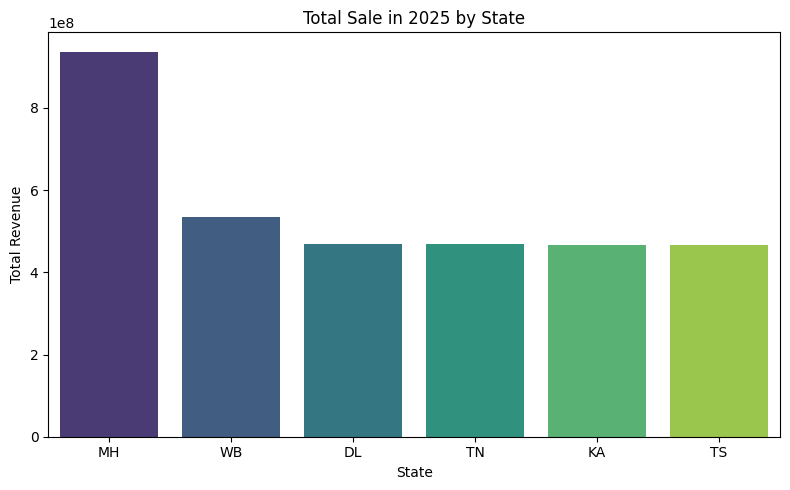

In [24]:

plt.figure(figsize=(8, 5))
sns.barplot(x=amount_by_state.index, y=amount_by_state.values, palette="viridis")
plt.title('Total Sale in 2025 by State')
plt.xlabel('State')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

* top products chart

In [25]:
order_items.head()

,order_id,product_id,quantity,unit_price,discount,net_amount
0,Byk-0,6514,3,3614.06,275.99,10566.19
1,Byk-0,2222,4,4539.08,1090.19,17066.13
2,Byk-0,40137,4,85.64,12.91,329.65
3,Byk-1,48440,3,1384.96,317.69,3837.19
4,Byk-1,52122,1,3002.00,108.78,2893.22


In [26]:
data_product = pd.merge(products, order_items, on='product_id', how='inner', suffixes=('_product', '_order_item'))
data_product

,product_id,brand,category,sub_category,mrp,order_id,quantity,unit_price,discount,net_amount
0,0,Nykaa Naturals,Fragrance,Compact,4833.00,Byk-20574,1,3300.79,179.52,3121.27
1,1,Lakme,Personal Care,Serum,710.60,Byk-64542,3,2749.19,602.48,7645.09
2,2,Nykaa Naturals,Personal Care,Eyeliner,3217.86,Byk-40949,4,2211.00,618.97,8225.03
3,2,Nykaa Naturals,Personal Care,Eyeliner,3217.86,Byk-85000,4,172.01,15.85,672.19
4,3,WOW Skin Science,Skincare,Sanitizer,4979.63,Byk-12365,2,1365.86,238.33,2493.39
...,...,...,...,...,...,...,...,...,...,...
199698,99999,Forest Essentials,Skincare,Serum,4921.97,Byk-14461,3,2806.55,758.52,7661.13
199699,99999,Forest Essentials,Skincare,Serum,4921.97,Byk-15160,3,2828.42,258.14,8227.12
199700,99999,Forest Essentials,Skincare,Serum,4921.97,Byk-33867,5,1442.80,201.43,7012.57
199701,99999,Forest Essentials,Skincare,Serum,4921.97,Byk-45924,4,4126.62,218.51,16287.97


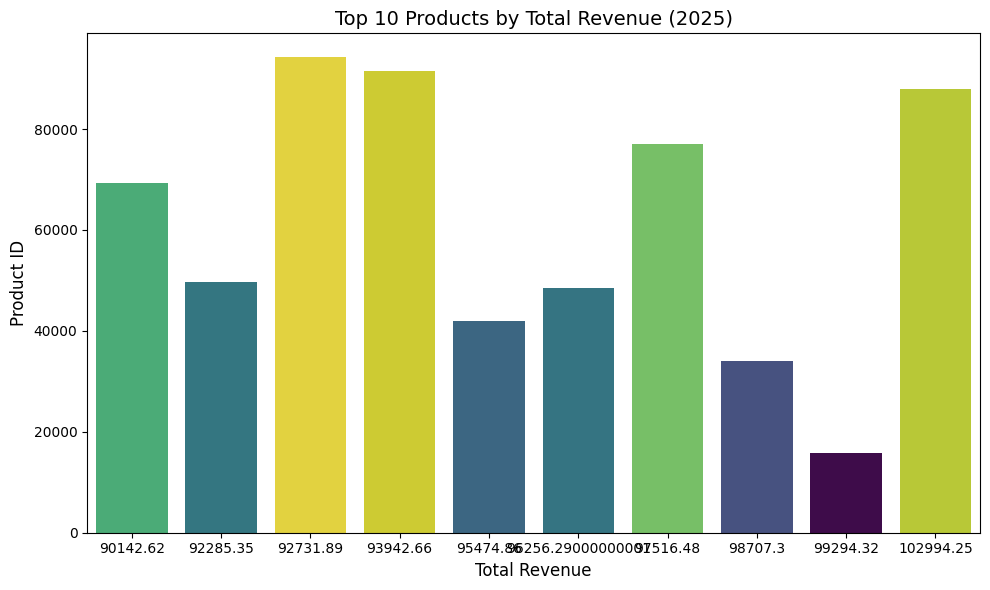

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data
df_top_10 = (data_product.groupby(['product_id', 'brand'])['net_amount']
               .sum()
               .reset_index(name='total_net_amount')
               .sort_values(by='total_net_amount', ascending=False)
               .head(10))

# 2. Plotting
plt.figure(figsize=(10, 6))

# Map 'y' to 'hue' to satisfy the new requirement
sns.barplot(
    data=df_top_10,
    x='total_net_amount', 
    y='product_id', 
    hue='product_id',  # Explicitly link colors to the ID
    palette='viridis', 
    legend=False       # Hide the legend since the Y-axis already labels the bars
)

plt.title('Top 10 Products by Total Revenue (2025)', fontsize=14)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product ID', fontsize=12)

plt.tight_layout()
plt.show()
   

* Order distribution

/var/folders/3b/8cnrvmc53q97m9nqbnvfytlm0000gn/T/ipykernel_2489/342715490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_products['total_net_amount'], y=df_products['brand'], palette='viridis')


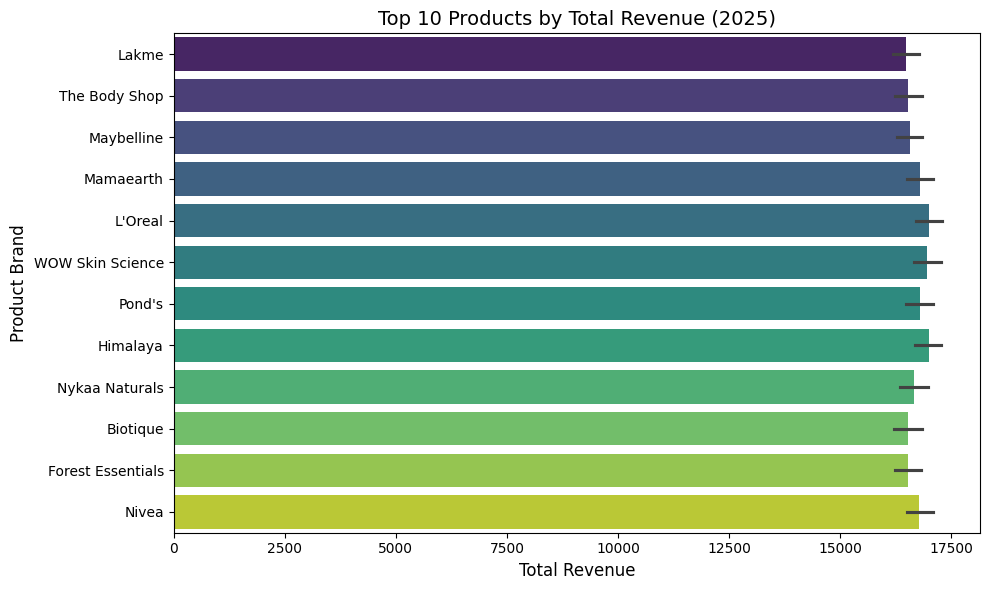

In [28]:
# Group and take the Top 10 for better readability
df_products = (data_product.groupby(['product_id', 'brand'])['net_amount']
               .sum()
               .reset_index(name='total_net_amount')
               .sort_values(by='total_net_amount', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=df_products['total_net_amount'], y=df_products['brand'], palette='viridis')

plt.title('Top 10 Products by Total Revenue (2025)', fontsize=14)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Brand', fontsize=12)

plt.tight_layout()
plt.show()